# 01_Preprocesamiento_PCAP_UNAD_PROYECTO_APLICADO

Configuración, conversión PCAP→CSV y validación del CSV.

In [1]:
from pathlib import Path
import shutil, subprocess, sys, time
import importlib.metadata as md
import pandas as pd

pd.set_option("display.max_columns",200)
pd.set_option("display.width",200)

REPO_ROOT = Path.cwd().parent
PCAP_DIR=REPO_ROOT/"pcap_files"
CSV_DIR=REPO_ROOT/"csv_raw"
TMP_DIR=REPO_ROOT/".tmp_cicflowmeter"
for d in (PCAP_DIR,CSV_DIR,TMP_DIR):
    d.mkdir(parents=True,exist_ok=True)

print("Python:",sys.version.split()[0])
for p in ["pandas","scapy","cicflowmeter"]:
    try:
        print(f"{p}: {md.version(p)}")
    except Exception:
        print(f"{p}: no disponible")
print("cicflowmeter:",shutil.which("cicflowmeter"))


Python: 3.8.18
pandas: 2.0.3
scapy: 2.4.3
cicflowmeter: 0.1.6
cicflowmeter: /usr/local/bin/cicflowmeter


In [2]:
pcaps=sorted(PCAP_DIR.glob("*.pcap"))
if not pcaps:
    raise FileNotFoundError(f"No hay archivos .pcap en {PCAP_DIR}")
PCAP_PATH=pcaps[0]
TMP_CSV=TMP_DIR/f"{PCAP_PATH.stem}.csv"
CSV_PATH=CSV_DIR/f"{PCAP_PATH.stem}.csv"
print("PCAP:",PCAP_PATH)


PCAP: /workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/pcap_files/DoS-TCP_Flood10.pcap


In [5]:
def run_cicflowmeter(pcap_path,out_csv):
    if out_csv.exists():
        out_csv.unlink()
        
    cmd=["cicflowmeter","-f",str(pcap_path),"-c",str(out_csv)]
    print(" ".join(cmd))
    t0=time.time()
    r=subprocess.run(cmd,capture_output=True,text=True)
    print("Return:",r.returncode)
    print("Tiempo(s):",round(time.time()-t0,2))
    print("STDERR:\n",r.stderr or "(vacío)")
    return r

r=run_cicflowmeter(PCAP_PATH,TMP_CSV)
if r.returncode!=0:
    raise RuntimeError("cicflowmeter falló")


cicflowmeter -f /workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/pcap_files/DoS-TCP_Flood10.pcap -c /workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/.tmp_cicflowmeter/DoS-TCP_Flood10.csv
Return: -15
Tiempo(s): 224.17
STDERR:
 reading from file /workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/pcap_files/DoS-TCP_Flood10.pcap, link-type EN10MB (Ethernet), snapshot length 262144



RuntimeError: cicflowmeter falló

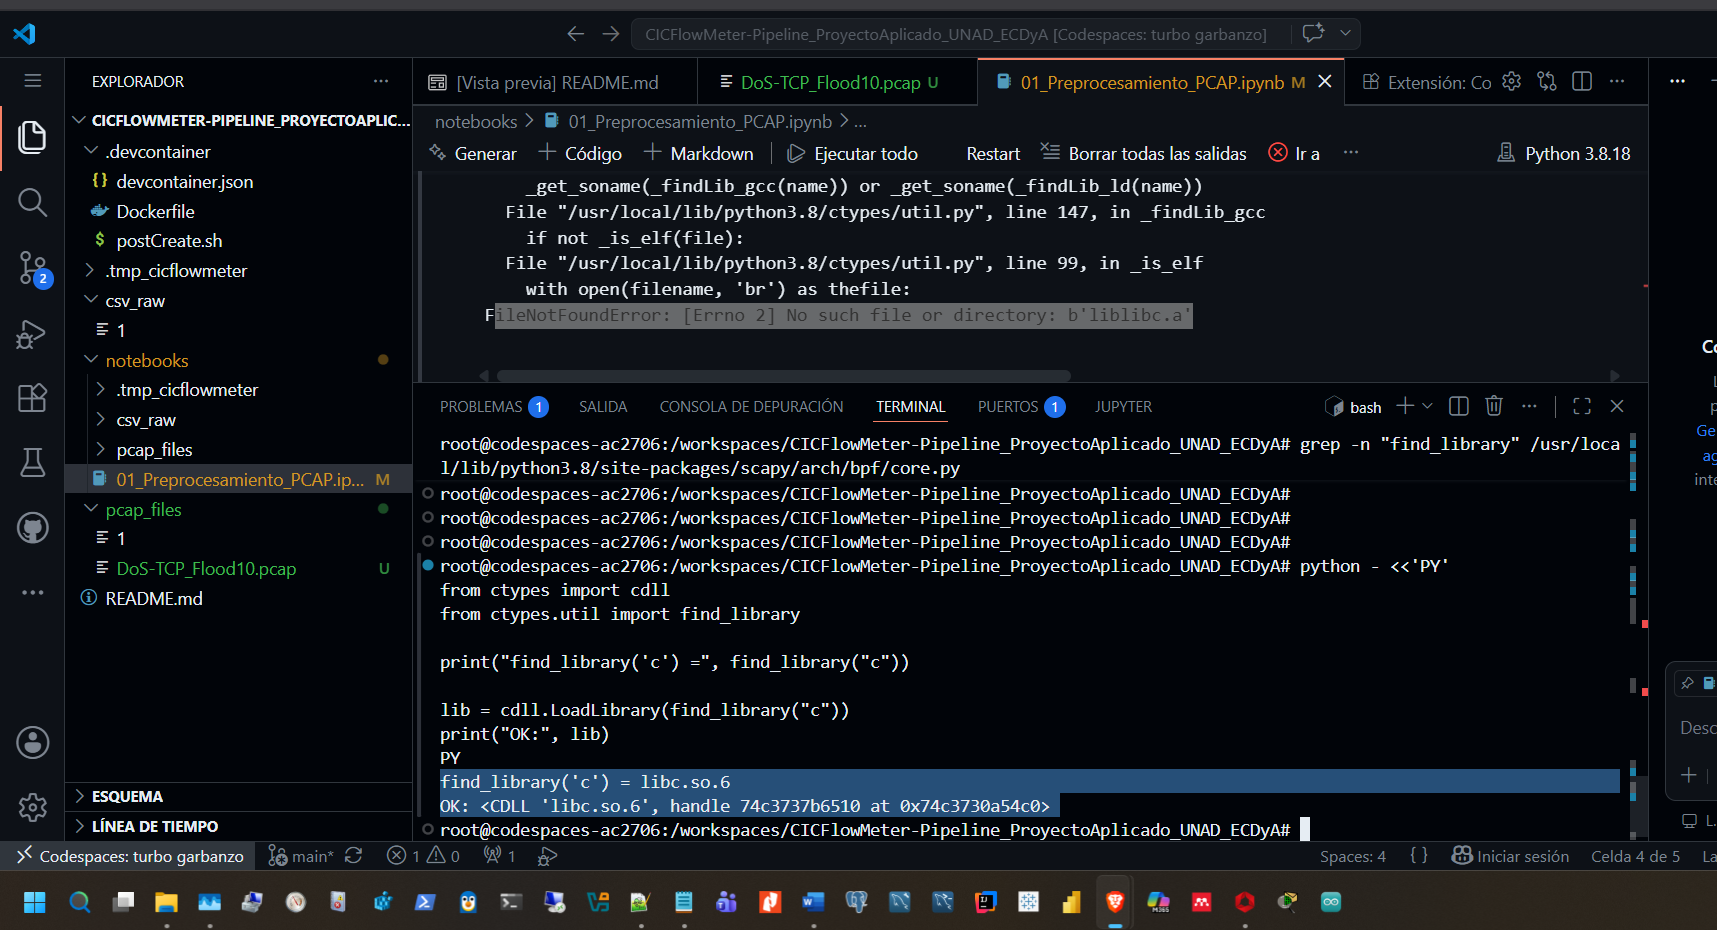

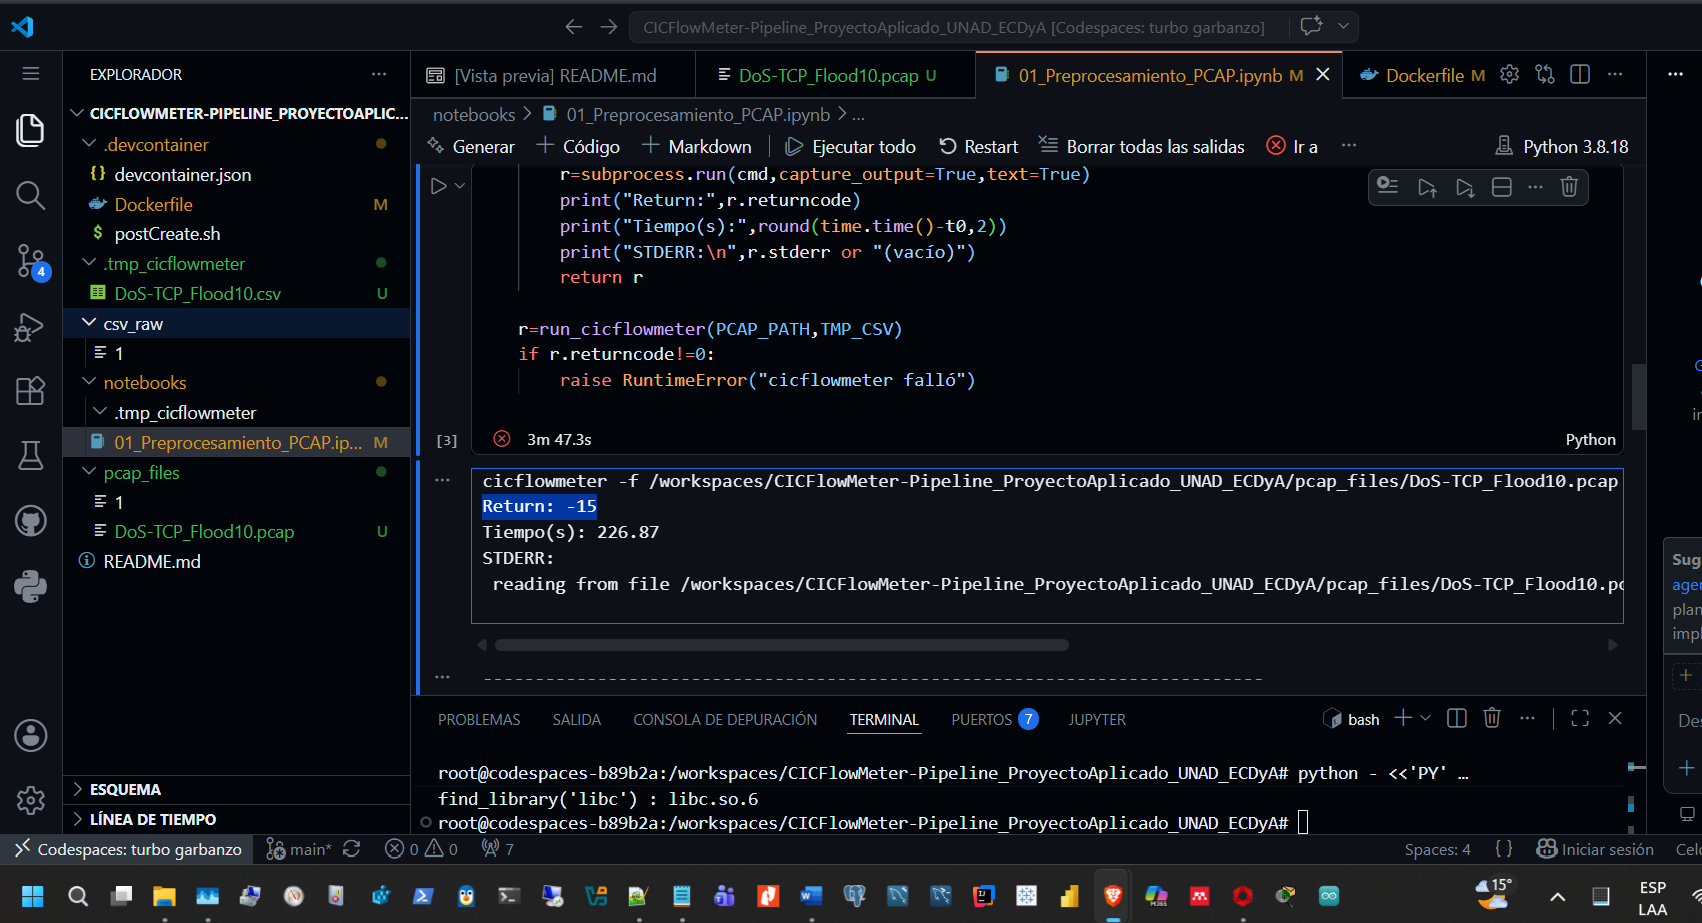

In [ ]:
import os
import subprocess
import time
from pathlib import Path
import pandas as pd

# --- Tus variables originales ---
PCAP_PATH = Path("/workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/pcap_files/DoS-TCP_Flood10.pcap")
TMP_DIR = Path("/workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/.tmp_cicflowmeter")
TMP_CSV = TMP_DIR / "DoS-TCP_Flood10.csv"
TMP_DIR.mkdir(parents=True, exist_ok=True)

def run_cicflowmeter(pcap_path, out_csv):
    if out_csv.exists():
        out_csv.unlink()
        
    cmd = ["cicflowmeter", "-f", str(pcap_path), "-c", str(out_csv)]
    print(f"Ejecutando: {' '.join(cmd)}")
    t0 = time.time()
    
    # Optimizamos text=True y evitamos capturas masivas en memoria si el stderr es gigante
    r = subprocess.run(cmd, capture_output=True, text=True)
    
    print("Return:", r.returncode)
    print("Tiempo(s):", round(time.time() - t0, 2))
    if r.returncode != 0:
        print("STDERR:\n", r.stderr or "(vacío)")
    return r

# --- ESTRATEGIA DE FRAGMENTACIÓN ---
print("--- Iniciando segmentación de PCAP pesado ---")
chunk_prefix = TMP_DIR / "split_chunk_"

# Dividir el PCAP en fragmentos de 20MB cada uno usando tcpdump (No consume casi RAM)
split_cmd = ["tcpdump", "-r", str(PCAP_PATH), "-C", "20", "-w", str(chunk_prefix)]
subprocess.run(split_cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

# Listar todos los fragmentos generados por tcpdump
chunks = sorted(list(TMP_DIR.glob("split_chunk_*")))
print(f"Se generaron {len(chunks)} fragmentos para procesar.")

csv_outputs = []

# Procesar cada fragmento individualmente
for idx, chunk in enumerate(chunks):
    print(f"\n[Progreso: {idx+1}/{len(chunks)}] Procesando fragmento...")
    chunk_csv = chunk.with_suffix(".csv")
    
    res = run_cicflowmeter(chunk, chunk_csv)
    
    if res.returncode == 0 and chunk_csv.exists():
        csv_outputs.append(chunk_csv)
    else:
        print(f"Advertencia: El fragmento {chunk.name} no generó datos válidos.")
        
    # Limpieza inmediata del archivo PCAP temporal para recuperar espacio en disco/RAM
    chunk.unlink()

# --- CONSOLIDACIÓN FINAL ---
if csv_outputs:
    print("\n--- Consolidando resultados finales ---")
    # Leer y concatenar todos los CSV temporales en un DataFrame
    df_conglomerado = pd.concat([pd.read_csv(f) for f in csv_outputs], ignore_index=True)
    
    # Guardar en la ubicación de tu CSV final original
    df_conglomerado.to_csv(TMP_CSV, index=False)
    print(f"¡Éxito! Pipeline finalizado. Archivo guardado en: {TMP_CSV}")
    
    # Limpiar CSVs temporales fragmentados
    for f in csv_outputs:
        f.unlink()
else:
    raise RuntimeError("No se pudo procesar ningún fragmento del archivo PCAP.")

--- Iniciando segmentación de PCAP pesado ---
Se generaron 33 fragmentos para procesar.

[Progreso: 1/33] Procesando fragmento...
Ejecutando: cicflowmeter -f /workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/.tmp_cicflowmeter/split_chunk_ -c /workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/.tmp_cicflowmeter/split_chunk_.csv
Return: 0
Tiempo(s): 208.43

[Progreso: 2/33] Procesando fragmento...
Ejecutando: cicflowmeter -f /workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/.tmp_cicflowmeter/split_chunk_1 -c /workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/.tmp_cicflowmeter/split_chunk_1.csv
Return: 0
Tiempo(s): 190.55

[Progreso: 3/33] Procesando fragmento...
Ejecutando: cicflowmeter -f /workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/.tmp_cicflowmeter/split_chunk_10 -c /workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/.tmp_cicflowmeter/split_chunk_10.csv
Return: 0
Tiempo(s): 194.56

[Progreso: 4/33] Procesando frag

: 

In [ ]:
from pandas.errors import EmptyDataError

if not TMP_CSV.exists():
    raise FileNotFoundError(TMP_CSV)

with open(TMP_CSV,"rb") as f:
    head=f.read(300)

if head.strip()==b"":
    raise RuntimeError(f"CSV inválido. Primeros bytes: {head!r}")

try:
    df=pd.read_csv(TMP_CSV,low_memory=False)
except EmptyDataError:
    raise RuntimeError(f"CSV sin columnas. Primeros bytes: {head!r}")

if df.empty or df.shape[1]==0:
    raise RuntimeError("CSV vacío o sin columnas")

shutil.copy2(TMP_CSV,CSV_PATH)

print("CSV válido:",CSV_PATH)
print("Shape:",df.shape)
display(df.head())
